# **Task 1: Binary Classification**

This notebook is for the Flight Delay prediction project. In this notebook the binary classification task is implemented. The two classes are delayed or not. A delay is defined as the plane leaving 15 minutes after the scheduled department time.

In [ ]:
# Add access to Google Drive for data in Google Drive.
from google.colab import drive
import numpy as np
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Import statements and methods for entire notebook access.
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from scipy.sparse import hstack
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, roc_auc_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

import pandas as pd
import glob

def plot_cm(cm, title, labels):
    plt.figure()
    plt.imshow(cm, interpolation='nearest')
    plt.title(title)
    plt.colorbar()
    ticks = np.arange(len(labels))
    plt.xticks(ticks, labels, rotation=45, ha='right')
    plt.yticks(ticks, labels)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.show()

In [ ]:
#------------------------------
# Load data & test train split
#------------------------------

# File paths - From personal drive. Data flight information from 2014 and 2015.
file1 = "/content/drive/MyDrive/Junior Year/EE 344/Final Project Data/2014.csv"
file2 = "/content/drive/MyDrive/Junior Year/EE 344/Final Project Data/2015.csv"

# Columns to keep - Drop others to avoid data leakage.
columns_to_keep = [
    'FL_DATE', 'OP_CARRIER', 'ORIGIN', 'DEST', 'CRS_DEP_TIME',
    'CRS_ARR_TIME', 'CRS_ELAPSED_TIME', 'DISTANCE', 'CANCELLED',
    'CANCELLATION_CODE', 'DIVERTED', 'DEP_DELAY'
]

# Define smaller dtypes to save memory - Limited RAM in Colab.
dtypes = {
    'OP_CARRIER': 'category',
    'ORIGIN': 'category',
    'DEST': 'category',
    'CRS_DEP_TIME': 'int32',
    'CRS_ARR_TIME': 'int32',
    'CRS_ELAPSED_TIME': 'float32',
    'DISTANCE': 'float32',
    'CANCELLED': 'int8',
    'DIVERTED': 'int8',
    'DEP_DELAY': 'float32',
    'CANCELLATION_CODE': 'category'
}

# Read CSV files with selected columns and dtypes
df1 = pd.read_csv(file1, usecols=columns_to_keep, dtype=dtypes)
df2 = pd.read_csv(file2, usecols=columns_to_keep, dtype=dtypes)

# Combine into one DataFrame
all_data = pd.concat([df1, df2], ignore_index=True)

# Free memory from intermediate DataFrames
del df1, df2

# Convert date column to datetime
all_data.loc[:, 'FL_DATE'] = pd.to_datetime(all_data['FL_DATE'])

# Remove cancelled/diverted flights to reduce size
all_data = all_data[(all_data['CANCELLED'] == 0) & (all_data['DIVERTED'] == 0)].copy()

# Sort chronologically
all_data = all_data.sort_values("FL_DATE").reset_index(drop=True)

# 70/30 chronological train/test split
split_index = int(len(all_data) * 0.7)
train_df = all_data.iloc[:split_index].copy()
test_df  = all_data.iloc[split_index:].copy()

# Check date ranges - Ensure data leakage will not happen.
print(train_df["FL_DATE"].min(), "to", train_df["FL_DATE"].max())
print(test_df["FL_DATE"].min(), "to", test_df["FL_DATE"].max())

2014-01-01 00:00:00 to 2015-05-29 00:00:00
2015-05-29 00:00:00 to 2015-12-31 00:00:00


In [ ]:
# ------------------------
# Binary Classification Preprocessing
# ------------------------

# Method for preprocessing flight data - Adapted from universal approach for tasks necessary only to binary classification.
def preprocess_flight_data_binary(df):
    df = df.copy()

    # Ensure FL_DATE is datetime
    df['FL_DATE'] = pd.to_datetime(df['FL_DATE'])

    # Extract time features
    df['CRS_DEP_TIME'] = df['CRS_DEP_TIME'].fillna(0).astype(int)
    df['DEP_HOUR'] = df['CRS_DEP_TIME'] // 100  # Hour (0–23)

    df['DAY_OF_WEEK'] = df['FL_DATE'].dt.dayofweek
    df['MONTH'] = df['FL_DATE'].dt.month

    # Time-of-day category (used for tree models)
    def get_time_of_day(hour):
        if 5 <= hour < 12:
            return 'morning'
        elif 12 <= hour < 17:
            return 'afternoon'
        elif 17 <= hour < 21:
            return 'evening'
        else:
            return 'night'

    df['TIME_OF_DAY'] = df['DEP_HOUR'].apply(get_time_of_day)

    # Cyclic encoding (used for linear models)
    df['DEP_HOUR_SIN'] = np.sin(2 * np.pi * df['DEP_HOUR'] / 24)
    df['DEP_HOUR_COS'] = np.cos(2 * np.pi * df['DEP_HOUR'] / 24)

    df['DAY_OF_WEEK_SIN'] = np.sin(2 * np.pi * df['DAY_OF_WEEK'] / 7)
    df['DAY_OF_WEEK_COS'] = np.cos(2 * np.pi * df['DAY_OF_WEEK'] / 7)

    return df


# Apply preprocessing
train_data = preprocess_flight_data_binary(train_df)
test_data = preprocess_flight_data_binary(test_df)

print(train_data.head())

     FL_DATE OP_CARRIER ORIGIN DEST  CRS_DEP_TIME  DEP_DELAY  CRS_ARR_TIME  \
0 2014-01-01         AA    ICT  DFW          1135        9.0          1300   
1 2014-01-01         UA    SAN  SFO          1122       18.0          1257   
2 2014-01-01         UA    SFO  LAX          1631       -7.0          1804   
3 2014-01-01         UA    IAH  LAX          1318       25.0          1514   
4 2014-01-01         UA    AUS  DEN           751       -4.0           906   

   CANCELLED CANCELLATION_CODE  DIVERTED  CRS_ELAPSED_TIME  DISTANCE  \
0          0               NaN         0              85.0     328.0   
1          0               NaN         0              95.0     447.0   
2          0               NaN         0              93.0     337.0   
3          0               NaN         0             236.0    1379.0   
4          0               NaN         0             135.0     775.0   

   DEP_HOUR  DAY_OF_WEEK  MONTH TIME_OF_DAY  DEP_HOUR_SIN  DEP_HOUR_COS  \
0        11            

In [ ]:
#------------------------
# Create target and feature matrices
#------------------------

# Create binary target variable: 1 if departure delay > 15 minutes, else 0.
y_train = (train_data['DEP_DELAY'] > 15).astype(int)
y_test  = (test_data['DEP_DELAY'] > 15).astype(int)

# Define categorical columns of data for linear models.
categorical_cols = ['OP_CARRIER', 'ORIGIN', 'DEST', 'MONTH', 'DAY_OF_WEEK']

# Define numerical columns of data for linear models.
numeric_cols = [
    'DISTANCE',
    'CRS_ELAPSED_TIME',
    'DEP_HOUR_SIN',
    'DEP_HOUR_COS',
    'DAY_OF_WEEK_SIN',
    'DAY_OF_WEEK_COS'
]

# One hot encoding for categorical columns.
# Fit OneHotEncoder on training data only, then transform both train and test categorical features.
ohe = OneHotEncoder(drop='first', sparse_output=True, handle_unknown='ignore')
X_train_cat = ohe.fit_transform(train_data[categorical_cols])
X_test_cat = ohe.transform(test_data[categorical_cols])

# Scale the numerical columns.
# Fit StandardScaler on training numerical features only, then scale train and test data.
scaler = StandardScaler()
X_train_num = scaler.fit_transform(train_data[numeric_cols])
X_test_num = scaler.transform(test_data[numeric_cols])

# Combine
X_train_linear = hstack([X_train_num, X_train_cat], format='csr')
X_test_linear = hstack([X_test_num, X_test_cat], format='csr')

# Define categorical columns for tree models.
tree_categorical_cols = [
    'OP_CARRIER',
    'ORIGIN',
    'DEST',
    'MONTH',
    'DAY_OF_WEEK',
    'TIME_OF_DAY'
]

# Define numerical columns for tree models.
tree_numeric_cols = ['DISTANCE', 'CRS_ELAPSED_TIME']

# Tree models do not require feature scaling.
# Categorical variables are converted to integer category codes instead of one-hot encoding.
# Combine numeric and encoded categorical features for tree-based models
X_train_tree = pd.concat([
    train_data[tree_numeric_cols].astype('float32'),
    train_data[tree_categorical_cols].apply(lambda x: x.astype('category').cat.codes)
], axis=1)

X_test_tree = pd.concat([
    test_data[tree_numeric_cols].astype('float32'),
    test_data[tree_categorical_cols].apply(lambda x: x.astype('category').cat.codes)
], axis=1)

## Baseline:
The baseline model predicts every observation as the majority class of the training data. In this dataset most flights are not delayed so the baseline predicts that every single flight will be not delayed or delayed under 15 minutes.

The baseline is implemented to provide a base model to evaluate the performance of complex models. Our complex models should perform better than the baseline, shown by a higher F1 score.

Since there is a class imbalance (more flights are not delayed), the accuracy of the baseline model will be high. However the other metrics will be very low, the precision, recall and F1-score.


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Metric,Majority Baseline
0,F1 Score,0.000000
1,Accuracy,0.827459
2,Precision,0.000000
3,Recall,0.000000


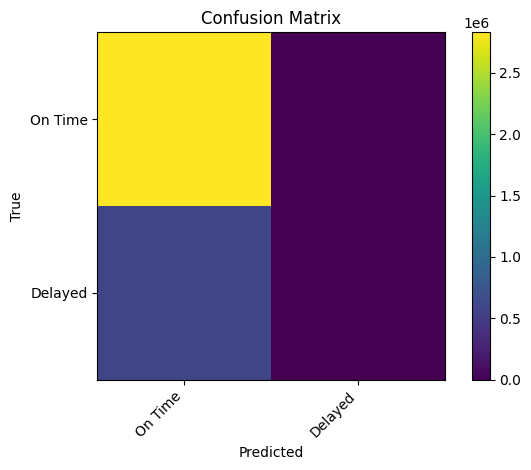

In [ ]:
# ---------------------
# Baseline
# ---------------------

# Majority baseline
majority_class = y_train.mode()[0]

y_pred_majority = np.full_like(y_test, majority_class)

# Create results table
baseline_results = pd.DataFrame({
    "Metric": ["F1 Score", "Accuracy", "Precision", "Recall"],
    "Majority Baseline": [
        f1_score(y_test, y_pred_majority),
        accuracy_score(y_test, y_pred_majority),
        precision_score(y_test, y_pred_majority),
        recall_score(y_test, y_pred_majority)
    ]
})

display(baseline_results)

#print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_majority))
plot_cm(confusion_matrix(y_test, y_pred_majority), "Confusion Matrix", ["On Time", "Delayed"])

## Baseline Results
The baseline model achieves an accuracy of 83%. However, the primary evaluation metric for this project is the F1 score, which is 0.0. This occurs because the baseline predicts every observation as the majority class (flights that are not delayed).

The high accuracy reflects the class imbalance in the dataset, where approximately 83% of flights are not delayed. While this results in a high accuracy, the model completely fails to identify delayed flights.

Both precision and recall are 0.0, indicating that the model never correctly predicts the delayed class. This demonstrates that accuracy alone is not an appropriate performance metric for imbalanced classification problems, and highlights the need for models that better capture the minority class.

In [ ]:
import gc
# Free memory immediately - Due to limited RAM.
del y_pred_majority
gc.collect()

4063

## Logistic Regression
Logistic Regression is the first machine learning model used in this project. It is a linear classification model that estimates the probability that a flight will be delayed using a logistic (sigmoid) function applied to a linear combination of the input features.

Unlike the baseline model, which predicts only the majority class, Logistic Regression attempts to learn relationships between the features and the target variable to distinguish between delayed and non-delayed flights.

Due to the class imbalance in the dataset, the model may not achieve higher accuracy than the baseline. However, it is expected to improve performance on more informative metrics such as precision, recall, and F1 score, which better capture the model’s ability to identify delayed flights.

,Logistic Regression
F1 Score,0.363822
Accuracy,0.606795
Precision,0.252360
Recall,0.651638
ROC-AUC,0.669614


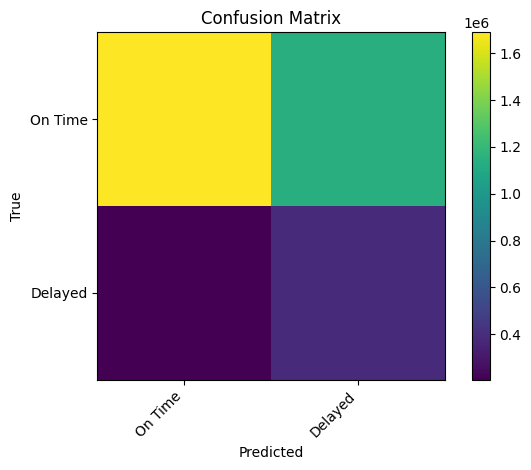

In [ ]:
# ---------------------
# Logistic Regression
# ---------------------

# Create logistic regression model.
log_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'  # handles imbalance
)

# Fit on training data.
log_model.fit(X_train_linear, y_train)

# Predict on test data.
y_pred_log = log_model.predict(X_test_linear)
y_prob_log = log_model.predict_proba(X_test_linear)[:, 1]

# Print results in a table.
log_results = pd.DataFrame({
    "Logistic Regression": [
        f1_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_log),
        roc_auc_score(y_test, y_prob_log)
    ]
}, index=["F1 Score", "Accuracy", "Precision", "Recall", "ROC-AUC"])

log_results

display(log_results)

#print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_log))
plot_cm(confusion_matrix(y_test, y_pred_log), "Confusion Matrix", ["On Time", "Delayed"])

## Logistic Regression Results
The Logistic Regression model achieves an accuracy of 61%, which is lower than the baseline accuracy of 83%. This is expected because the baseline always predicts the majority class, inflating accuracy in an imbalanced dataset.

However, the F1 score has increased to 36%, indicating that the model is correctly identifying a significant portion of delayed flights (the minority class). Precision is 25% and recall is 65%, showing that the model tends to catch more delayed flights, though with some false positives. The ROC-AUC of 0.67 further demonstrates that the model has learned meaningful patterns beyond the majority-class baseline.

Key takeaway: While accuracy decreased compared to the baseline, the model improves performance on metrics that better reflect minority class detection, making it a more useful predictor for flight delays.



In [ ]:
# After fitting Logistic Regression
del X_train_linear, X_test_linear
gc.collect()

8562

## Random Forest

The Random Forest model is implemented to determine whether non-linear relationships and complex feature interactions exist in the dataset that may not be captured by linear models such as Logistic Regression. Random Forest is an ensemble method that builds many decision trees and combines their predictions, allowing it to model more flexible decision boundaries.

This model is used to evaluate whether a more flexible, non-linear approach improves prediction performance compared to the linear baseline.

,Random Forest
F1 Score,0.330455
Accuracy,0.598160
Precision,0.231894
Recall,0.574727
ROC-AUC,0.625944


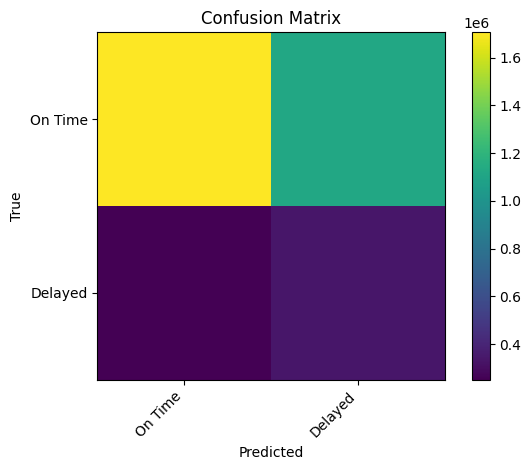

In [ ]:
# ---------------------
# Random Forest
# ---------------------

# Initialize Random Forest model.
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Fit on training data.
rf_model.fit(X_train_tree, y_train)

# Predict on test data.
y_pred_rf = rf_model.predict(X_test_tree)
y_prob_rf = rf_model.predict_proba(X_test_tree)[:, 1]

# Print results in a table.
rf_results = pd.DataFrame({
    "Random Forest": [
        f1_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_rf),
        roc_auc_score(y_test, y_prob_rf)
    ]
}, index=["F1 Score", "Accuracy", "Precision", "Recall", "ROC-AUC"])

display(rf_results)
plot_cm(confusion_matrix(y_test, y_pred_rf), "Confusion Matrix", ["On Time", "Delayed"])

## Random Forest Results

The Random Forest model achieves an F1 score of 33% and an accuracy of 60%, which is lower than the Logistic Regression model. Precision is 23% and recall is 57%, with a ROC-AUC of 0.63.

The decrease in performance compared to the linear model suggests that this problem does not contain strong non-linear relationships that would benefit from a tree-based or gradient boosting approach. In other words, the simpler linear relationships captured by Logistic Regression are sufficient for predicting flight delays in this dataset.

Key takeaway: For this dataset, linear models outperform Random Forest, highlighting that more complex non-linear models are not necessarily better when the underlying relationships are mostly linear.

## XGBClassifier

The XGBClassifier model is implemented to evaluate whether a gradient boosting approach can improve prediction performance compared to the previous models. Although the Random Forest model performed worse than the Logistic Regression, by including this model we can see if a more advanced boosting method is better than the tree-based model.

XGBoost builds an ensemble of decision trees sequentially, where each new tree focuses on correcting the errors made by the previous ones. This allows the model to capture complex non-linear relationships and interactions between features.



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:31:18] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,XGBoost
F1 Score,0.299841
Accuracy,0.643743
Precision,0.226843
Recall,0.442115
ROC-AUC,0.605900


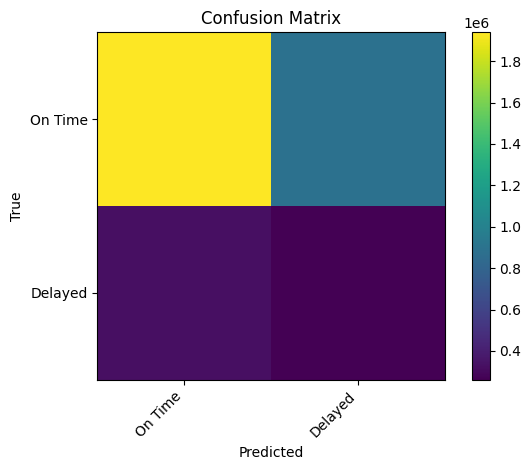

In [ ]:
# ---------------------
# XGBClassifier
# ---------------------
from xgboost import XGBClassifier

scale_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    scale_pos_weight=scale_weight,
    random_state=42,
    n_jobs=-1,
    use_label_encoder=False,
    eval_metric='logloss'
)

# Fit
xgb_model.fit(X_train_tree, y_train)

# Predict
y_pred_xgb = xgb_model.predict(X_test_tree)
y_prob_xgb = xgb_model.predict_proba(X_test_tree)[:, 1]

# Evaluate
xgb_results = pd.DataFrame({
    "XGBoost": [
        f1_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_xgb),
        precision_score(y_test, y_pred_xgb),
        recall_score(y_test, y_pred_xgb),
        roc_auc_score(y_test, y_prob_xgb)
    ]
}, index=["F1 Score", "Accuracy", "Precision", "Recall", "ROC-AUC"])
display(xgb_results)
plot_cm(confusion_matrix(y_test, y_pred_xgb), "Confusion Matrix", ["On Time", "Delayed"])

## XBGClassifier Results

This model actually performs worse than the Random Forest and as expected Logistic Regression. Although it has a powerful gradient boosting algorithm to capture complex relationships, that does not improve performance as the relationships within this data are not complex.

The XGBClassifier achieves an F1 score of 0.30 and an accuracy of 64%, which is lower than both the Logistic Regression and Random Forest models. Precision is 0.23 and recall is 0.44, with a ROC-AUC of 0.61.



In [ ]:
#----------------------------
# Results Comparison Table
#----------------------------

# Majority baseline predictions
y_pred_majority = np.full(y_test.shape, int(y_train.mode()[0]))

results_full = pd.DataFrame({
    "Model": ["Majority Baseline", "Logistic Regression", "Random Forest", "XGBoost"],
    "F1": [
        f1_score(y_test, y_pred_majority, zero_division=0),
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb)
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_majority),
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],
    "Precision": [
        precision_score(y_test, y_pred_majority, zero_division=0),
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb)
    ],
    "Recall": [
        recall_score(y_test, y_pred_majority, zero_division=0),
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb)
    ],
    "ROC-AUC": [
        None,
        roc_auc_score(y_test, y_prob_log),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb)
    ]
})

results_full.iloc[:, 1:] = results_full.iloc[:, 1:].round(4)

results_full

,Model,F1,Accuracy,Precision,Recall,ROC-AUC
0,Majority Baseline,0.0000,0.8275,0.0000,0.0000,NaN
1,Logistic Regression,0.3638,0.6068,0.2524,0.6516,0.6696
2,Random Forest,0.3305,0.5982,0.2319,0.5747,0.6259
3,XGBoost,0.2998,0.6437,0.2268,0.4421,0.6059


In [ ]:
# Just the F1 Scores, since they are our primary metric

results_f1 = results_full[["Model", "F1"]].sort_values(by="F1", ascending=False)

results_f1

,Model,F1
1,Logistic Regression,0.3638
2,Random Forest,0.3305
3,XGBoost,0.2998
0,Majority Baseline,0.0000


## Results Evaluation:

The tables above present a comparison of model performance across all evaluation metrics, as well as a separate table comparing F1 scores, which is the primary metric used in this analysis. The F1 score is emphasized because the dataset is imbalanced, and it provides a better measure of model performance by balancing precision and recall.

Logistic regression is the 'winner' (highest performing model) since it has the highest F1 score. The baseline had the highest accuracy due to the fact that it predicted all majority class and this is an inbalanced dataset. The high accuracy is artifically high due to failing to correctly identify any delayed flights.

While it is best based on this dataset, the logistic regression still had a low F1 score for a good model (a model that would be good at this task) since it has limited data inputs. It had limited predictive capabilities based on this dataset. Flight delays are affected by many factors that are not included in this dataset, especially weather, airport congestion, etc.

Below there is further analysis of the feature importance and error analysis.

## Feature Breakdown:

In [ ]:
import pandas as pd
import numpy as np

# Numeric + cyclic features
numeric_cols_linear = ['DISTANCE', 'CRS_ELAPSED_TIME', 'DEP_HOUR_SIN', 'DEP_HOUR_COS', 'DAY_OF_WEEK_SIN', 'DAY_OF_WEEK_COS']

# Categorical columns (for one-hot)
categorical_cols_linear = ['OP_CARRIER', 'ORIGIN', 'DEST', 'MONTH', 'DAY_OF_WEEK']

# Reconstruct one-hot feature names
onehot_feature_names = []

for col in categorical_cols_linear:
    categories = sorted(train_data[col].dropna().unique())
    onehot_feature_names.extend([f"{col}_{cat}" for cat in categories[1:]])

# Combine numeric + one-hot features
all_feature_names = numeric_cols_linear + onehot_feature_names

# Get coefficients
coefficients = log_model.coef_[0]

# Create DataFrame
coef_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Coefficient": coefficients
}).sort_values(by="Coefficient", key=abs, ascending=False)

# Show top 20 by absolute impact
coef_df.head(20)


,Feature,Coefficient
660,DEST_TTN,0.839535
160,ORIGIN_GUM,0.745649
254,ORIGIN_ORD,0.727577
332,ORIGIN_TTN,0.725878
12,OP_CARRIER_HA,-0.718632
464,DEST_FLG,-0.708845
632,DEST_SFO,0.697230
19,OP_CARRIER_WN,0.687002
676,DEST_YUM,-0.681065
596,DEST_PIH,-0.678514


## Results:
The table above shows the 20 most impactful features in the logistic regression model. Their value corresponds to the increase or decrease in probability that a flight will be delayed by more than 15 minutes.

Most of these features were origin and destination airports, suggesting that airport location is an important predictor of delays. For example (in 2014 and 2015) leaving from GUM, ORD, and TTN increased your chance of your flight being delayed. Having a flight going to TTN or SFO also increased that chance.

Airline carriers also appeared (although less) in the top 20 features. Southwest Airlines is likely to have a delayed flight while Hawaiian Airlines is below the baseline (lower probability of delay).

These results show that airport traffic levels and airline operations have a strong influence on delay patterns.


## Error Analysis

This section analyzes model errors by airport, airline, and time of day. The goal is to determine whether the model performs worse for certain groups of flights. By examining where incorrect predictions occur, we can identify patterns that may explain model limitations and highlight situations where the model struggles to accurately predict delays.

In [ ]:
# Copy test_data for evaluation
test_eval = test_data.copy()
test_eval['y_true'] = y_test.values
test_eval['y_pred'] = log_model.predict(X_test_linear)

# Breakdown by Airline
breakdown_airline = test_eval.groupby('OP_CARRIER').apply(
    lambda x: pd.Series({
        'Flights': len(x),
        'F1': f1_score(x['y_true'], x['y_pred']),
        'Precision': precision_score(x['y_true'], x['y_pred'], zero_division = 0),
        'Recall': recall_score(x['y_true'], x['y_pred']),
        'Accuracy': accuracy_score(x['y_true'], x['y_pred'])
    }),
    include_groups = False
).sort_values(by='F1', ascending=False)

# Breakdown by Origin Airport
breakdown_origin = test_eval.groupby('ORIGIN').apply(
    lambda x: pd.Series({
        'Flights': len(x),
        'F1': f1_score(x['y_true'], x['y_pred']),
        'Precision': precision_score(x['y_true'], x['y_pred'], zero_division = 0),
        'Recall': recall_score(x['y_true'], x['y_pred']),
        'Accuracy': accuracy_score(x['y_true'], x['y_pred'])
    }),
    include_groups = False
).sort_values(by='F1', ascending=False)

# Breakdown by Time of Day
breakdown_time = test_eval.groupby('TIME_OF_DAY').apply(
    lambda x: pd.Series({
        'Flights': len(x),
        'F1': f1_score(x['y_true'], x['y_pred']),
        'Precision': precision_score(x['y_true'], x['y_pred'], zero_division = 0),
        'Recall': recall_score(x['y_true'], x['y_pred']),
        'Accuracy': accuracy_score(x['y_true'], x['y_pred'])
    }),
    include_groups = False
).sort_values(by='F1', ascending=False)

# Display results
print("=== Breakdown by Airline ===")
display(breakdown_airline.head(10))

print("\n=== Breakdown by Origin Airport ===")
display(breakdown_origin.head(10))

print("\n=== Breakdown by Time of Day ===")
display(breakdown_time)

=== Breakdown by Airline ===


,Flights,F1,Precision,Recall,Accuracy
OP_CARRIER,,,,,
NK,70896.0,0.453912,0.320271,0.778947,0.492679
WN,745259.0,0.422991,0.282706,0.839641,0.531673
B6,158363.0,0.421982,0.301001,0.705568,0.595979
UA,310102.0,0.411951,0.286676,0.731695,0.537430
F9,56125.0,0.361035,0.241827,0.712028,0.497105
US,35828.0,0.337433,0.240349,0.566096,0.637630
EV,319346.0,0.319348,0.207319,0.694792,0.523075
VX,37959.0,0.318849,0.250583,0.438236,0.673358
AA,503161.0,0.317688,0.222173,0.557263,0.625064



=== Breakdown by Origin Airport ===


,Flights,F1,Precision,Recall,Accuracy
ORIGIN,,,,,
MMH,10.0,0.750000,0.666667,0.857143,0.600000
ASE,1269.0,0.501773,0.365633,0.799435,0.557132
UST,94.0,0.500000,0.356164,0.838710,0.446809
PUB,8.0,0.500000,0.333333,1.000000,0.750000
MVY,202.0,0.480315,0.316062,1.000000,0.346535
RDD,420.0,0.456522,0.307317,0.887324,0.642857
OAK,27851.0,0.454440,0.314326,0.819937,0.593695
PBI,12693.0,0.453595,0.315407,0.807290,0.604822
BWI,56847.0,0.451902,0.314604,0.801837,0.541752



=== Breakdown by Time of Day ===


,Flights,F1,Precision,Recall,Accuracy
TIME_OF_DAY,,,,,
afternoon,1019175.0,0.349607,0.226855,0.761847,0.456060
evening,767968.0,0.423057,0.276024,0.905284,0.374724
morning,1404688.0,0.166661,0.205917,0.139976,0.854851
night,225885.0,0.424201,0.300827,0.719122,0.533342


##Results:
The model’s predictive performance varies across different flight conditions. For example, prediction performance is substantially lower for morning flights compared to evening and night flights. This may reflect the propagation of delays throughout the day, where earlier flights are less affected by prior delays while later flights are more predictable due to accumulated disruptions. Model performance also differs by airport, suggesting that local operational factors may influence delay patterns. While some airlines achieve slightly better accuracy than others, the differences across carriers are relatively small, suggesting that airport conditions may play a more significant role in predicting delays than the airline operating the flight.
